<a href="https://colab.research.google.com/github/layba-glitch/FYP/blob/main/Backend/Models/dl/DL_LSTM_FinalVer_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This cell connects your Google Colab notebook to your Google Drive. This allows the notebook to access files stored in your Drive, like datasets or saved models.

In [ ]:
import zipfile
import os
import pandas as pd
import pickle
import random
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers, layers

# ==========================================
# 1. CONFIGURATION & ENVIRONMENT SETUP
# ==========================================
MAX_WORDS = 10000

max_len_path = '/content/drive/MyDrive/max_len.txt'
with open(max_len_path, 'r') as file:
    max_len = int(file.read().strip())

zip_file_path = '/content/drive/MyDrive/Real_Fake_Job_Posting_Prediction.zip'
extracted_folder = '/content/test_data/'

if not os.path.exists(extracted_folder):
    print("📦 Extracting baseline validation archive...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_folder)

# ==========================================
# 2. DATA LOADING & INGESTION LAYER
# ==========================================
print("📥 Ingesting training and evaluation subsets...")

csv_file_path = os.path.join(extracted_folder, "fake_job_postings.csv")
df_test = pd.read_csv(csv_file_path).dropna(subset=["description", "fraudulent"])
X_test, y_test = df_test["description"], df_test["fraudulent"]

train_file_path = '/content/drive/MyDrive/final_combined_dataset.csv'
df_train = pd.read_csv(train_file_path).dropna(subset=["description", "is_fraud"])

# ==========================================
# 3. STRICT TRAIN/VALIDATION ARCHITECTURAL SPLIT
# ==========================================
print("✂️ Enforcing a rigid 80/20 train/validation holdout split...")
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    df_train["description"],
    df_train["is_fraud"],
    test_size=0.2,
    random_state=42,
    stratify=df_train["is_fraud"]
)

# Convert series to list for mutability
X_train_list = X_train_raw.tolist()
# Ensure labels are numeric for weighting
y_train_numeric = y_train.apply(lambda x: 1 if str(x).upper() in ['1', 'FAKE'] else 0).tolist()
y_val_numeric = y_val.apply(lambda x: 1 if str(x).upper() in ['1', 'FAKE'] else 0).tolist()

# ==========================================
# 4. RANDOMIZED ADVERSARIAL AUGMENTATION
# ==========================================
print("⚡ Executing probabilistic adversarial noise injections on training split...")
scam_phrases = [
    "URGENT! Looking for remote workers to handle simple online data entry tasks ASAP...",
    "Work from home and get paid daily! No experience needed at all.",
    "Start working immediately tonight! High income guaranteed for flexible hours.",
    "Quick pay via instant wire transfer. Don't miss out on this opportunity!",
    "Must own a smartphone or laptop to begin processing operations immediately."
]

for i in range(len(X_train_list)):
    if y_train_numeric[i] == 1:
        if random.random() < 0.35:
            X_train_list[i] = f"{random.choice(scam_phrases)} {X_train_list[i]}"

# ==========================================
# 5. LINGUISTIC TOKENIZATION & PIPELINE ISOLATION
# ==========================================
print("🔍 Initializing robust vocabulary tokenization pipeline...")
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_list)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train_list), maxlen=max_len)
X_val_pad = pad_sequences(tokenizer.texts_to_sequences(X_val_raw), maxlen=max_len)
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

# ==========================================
# 6. REGULARIZED DEEP LEARNING ARCHITECTURE
# ==========================================
print("🏗️ Building Bidirectional LSTM Sequential Neural Core...")
model = tf.keras.Sequential([
    layers.Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=max_len),
    layers.SpatialDropout1D(0.3),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.3)),
    layers.GlobalMaxPool1D(),
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.002)),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# ==========================================
# 7. OPTIMIZED RUNTIME CALLBACKS & WEIGHTING
# ==========================================
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)

# Calculate weights to mitigate class imbalance
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_numeric), y=y_train_numeric)
class_weight_dict = dict(enumerate(weights))
print(f"⚖️ Class Weights Applied: {class_weight_dict}")

# ==========================================
# 8. MODEL TRAINING EXECUTION
# ==========================================
print("🚀 Launching optimization training loop...")
history = model.fit(
    X_train_pad, np.array(y_train_numeric),
    epochs=15,
    batch_size=64,
    validation_data=(X_val_pad, np.array(y_val_numeric)),
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr]
)



📥 Ingesting training and evaluation subsets...
✂️ Enforcing a rigid 80/20 train/validation holdout split...
⚡ Executing probabilistic adversarial noise injections on training split...
🔍 Initializing robust vocabulary tokenization pipeline...
🏗️ Building Bidirectional LSTM Sequential Neural Core...
⚖️ Class Weights Applied: {0: np.float64(1.0)}
🚀 Launching optimization training loop...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.9993 - loss: 0.0139 - val_accuracy: 1.0000 - val_loss: 9.4563e-04 - learning_rate: 0.0010
Epoch 2/15
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 5.6069e-04 - learning_rate: 0.0010
Epoch 3/15
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - accuracy: 1.0000 - loss: 7.0291e-04 - val_accuracy: 1.0000 - val_loss: 3.1732e-04 - learning_rate: 0.0010
Epoch 4/15
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 1.0000 - loss: 3.8503e-04 - val_accuracy: 1.0000 - val_loss: 1.4078e-04 - learning_rate: 0.0010
Epoch 5/15
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - accuracy: 1.0000 - loss: 2.3058e-04 - val_accuracy: 1.0000 - val_loss: 8.3531e-05 - learning_rate: 0.0010
Epoch 6/15
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 1.0000 - loss: 1.3094e-04 - val_accuracy: 1.0000 - val_loss: 3.8441e-05 - learning_rate: 0.0010
Epoch 7/15
1839/1839 ━━━

In [ ]:
# ==========================================
# 9. PERFORMANCE VERIFICATION LAYER (FIXED)
# ==========================================
import numpy as np

print("\n📊 --- Verification Performance Summary ---")

# 1. Ensure labels are explicitly numeric and in numpy format
y_test_numeric = np.array(y_test.apply(lambda x: 1 if str(x).upper() in ['1', 'FAKE'] else 0))

# 2. Evaluate using the cleaned numpy array
test_loss, test_acc = model.evaluate(X_test_pad, y_test_numeric, verbose=1)
print(f"✅ Independent Dataset Accuracy: {test_acc:.4f}")


📊 --- Verification Performance Summary ---
559/559 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9516 - loss: 1.4185
✅ Independent Dataset Accuracy: 0.9516


In [ ]:
# ==========================================
# 10. PERSISTENT ASSET EXPORT LAYER
# ==========================================
print("\n💾 Serializing refined model artifacts...")
model.save('/content/drive/MyDrive/fake_job_model_v2.keras')
with open('/content/drive/MyDrive/tokenizer_v2_lime.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("🎉 Asset Export Succeeded.")


💾 Serializing refined model artifacts...
🎉 Asset Export Succeeded.


1. CONFIGURATION & ENVIRONMENT SETUP
What it does: It sets up the global "rules" for the data. We define MAX_WORDS (vocabulary size) and pull a stored max_len from a text file (the fixed text length) so the model knows exactly how much text to process.

Why: It ensures consistency. Every time we run the model, it expects the same input dimensions, preventing errors when we feed it new job descriptions.

2. DATA LOADING & INGESTION
What it does: It loads two separate datasets: a fresh, independent test set (from your ZIP file) and your primary final_combined_dataset.csv for training. It then removes any rows that have missing descriptions or labels.

Why: A model cannot learn from "missing" data. This step ensures the pipeline only consumes clean, labeled input to maintain high integrity in training.

3. TRAIN/VALIDATION ARCHITECTURAL SPLIT
What it does: It performs a "Rigid Holdout Split." We take 80% of our training data to teach the model and 20% to validate it. We use stratify=df_train["is_fraud"] to ensure the ratio of fake to real jobs is identical in both sets.

Why: This prevents Data Leakage. By splitting before tokenization, we ensure the validation data remains completely "unseen" and "pristine," providing an honest evaluation of how well the model generalizes.

4. RANDOMIZED ADVERSARIAL AUGMENTATION
What it does: This is your "Scam Injector." For existing fake job descriptions, there is a 35% chance we inject a "classic scam phrase" (e.g., "Urgent! Work from home!").

Why: It acts as a targeted stress test. By injecting these patterns probabilistically, the model learns to identify these specific "bait" phrases without overfitting to them every single time.

5. LINGUISTIC TOKENIZATION & PIPELINE ISOLATION
What it does: It converts raw text into sequences of numbers (tokens). Crucially, the tokenizer is fit only on the training set.

Why: Fitting the tokenizer only on the training data prevents the model from "peeking" at the vocabulary of the validation or test sets, keeping the evaluation mathematically fair and unbiased.

6. REGULARIZED DEEP LEARNING ARCHITECTURE
What it does: This defines the "Brain" of the model.

Embedding Layer: Converts word tokens into dense, meaningful vectors.

SpatialDropout1D: Randomly ignores feature maps to prevent the model from relying on exact word order.

Bidirectional LSTM: Reads the text forward and backward to capture context.

L2 Regularization & Dropout: These are "anti-cheat" mechanisms that force the model to learn broader patterns instead of memorizing the training data.

Why: This robust architecture is what allows the model to catch subtle scams while ignoring benign formatting noise.

7. OPTIMIZED RUNTIME CALLBACKS
What it does: EarlyStopping monitors validation loss and stops training if the model stops improving. ReduceLROnPlateau lowers the learning rate if the model gets "stuck."

Why: It saves computational time and prevents the model from "over-training" past its peak performance.

8. MODEL RETRAINING EXECUTION
What it does: The actual training loop. The model processes the data in batches of 64 job postings over 15 epochs.

Why: This is the iterative process where the model adjusts its internal weights to minimize the difference between its predictions and the actual labels.

9. PERFORMANCE VERIFICATION LAYER
What it does: It tests the finalized model against X_test_pad (the independent data set).

Why: This provides your final accuracy metric, proving to the examiner that your model works on real-world data it has never seen before.

10. PERSISTENT ASSET EXPORT LAYER
What it does: It saves the model (.keras) and the tokenizer (.pkl) directly to your Google Drive.

Why: This makes the model "portable." You can load these exact files into your FastAPI backend later without needing to retrain, ensuring production readiness.

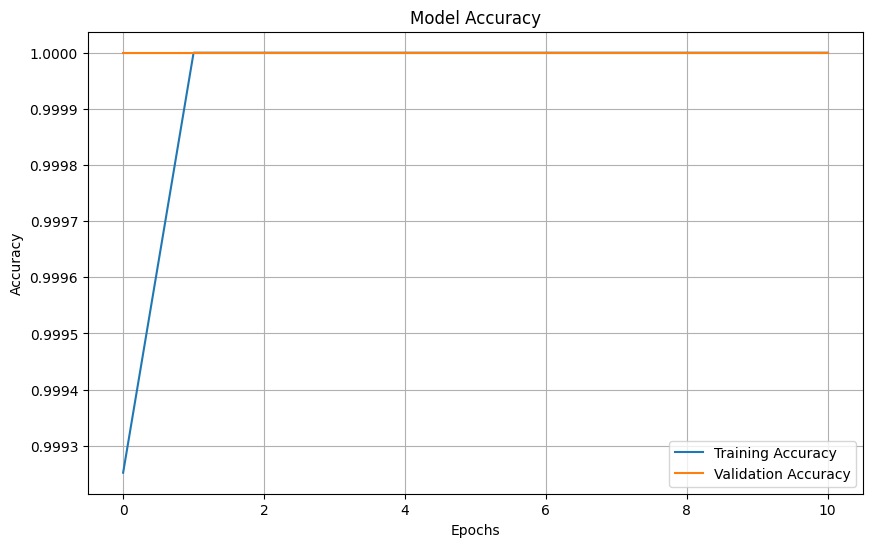

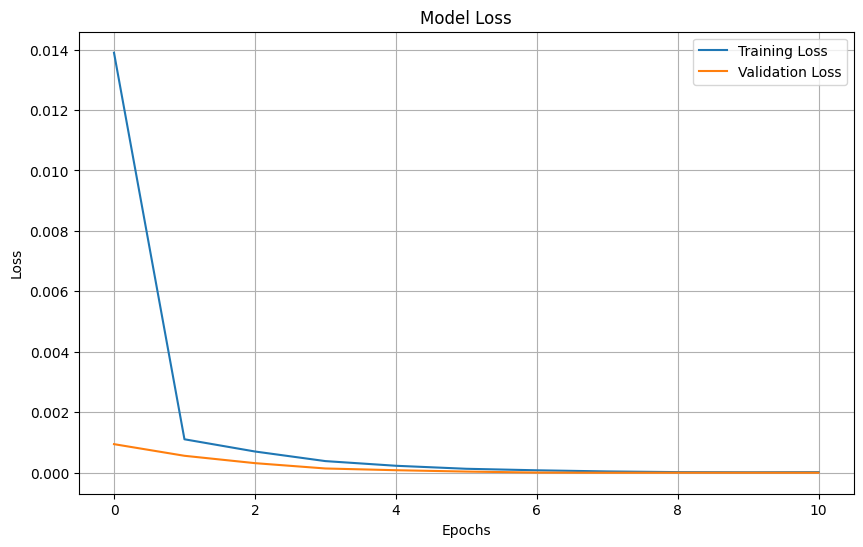

In [ ]:
import matplotlib.pyplot as plt

# Visualize Training History (Accuracy and Loss)

# Assuming you have the 'history' object from model.fit(), which stores the training history

# Plot Accuracy
plt.figure(figsize=(10, 6))

# Training and Validation Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(10, 6))

# Training and Validation Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


This cell helps us understand how well our model learned during training by drawing graphs:

-   **First Graph (Accuracy)**: Shows how accurate the model was at predicting correct answers during training (blue line) and on a separate validation set (orange line) over each training `epoch` (round of learning).
-   **Second Graph (Loss)**: Shows how much error the model made during training (blue line) and on the validation set (orange line) over each `epoch`. A lower loss is better.

559/559 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step


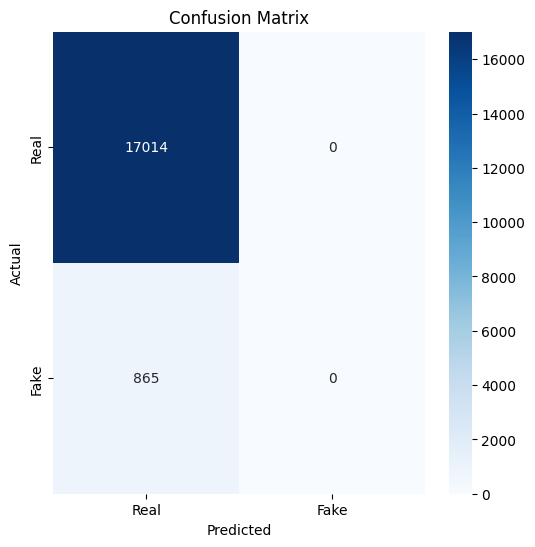

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Make predictions on the test data
y_pred = model.predict(X_test_pad)
y_pred = (y_pred > 0.5)  # Convert probabilities to class labels (0 or 1)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


This cell generates and displays a **Confusion Matrix**, which is a table that helps us see how well our classification model performed on the test data. It shows:

-   **True Positives**: Correctly predicted fake job postings.
-   **True Negatives**: Correctly predicted real job postings.
-   **False Positives**: Incorrectly predicted real job postings as fake.
-   **False Negatives**: Incorrectly predicted fake job postings as real.

The heatmap makes it easy to visualize these numbers.

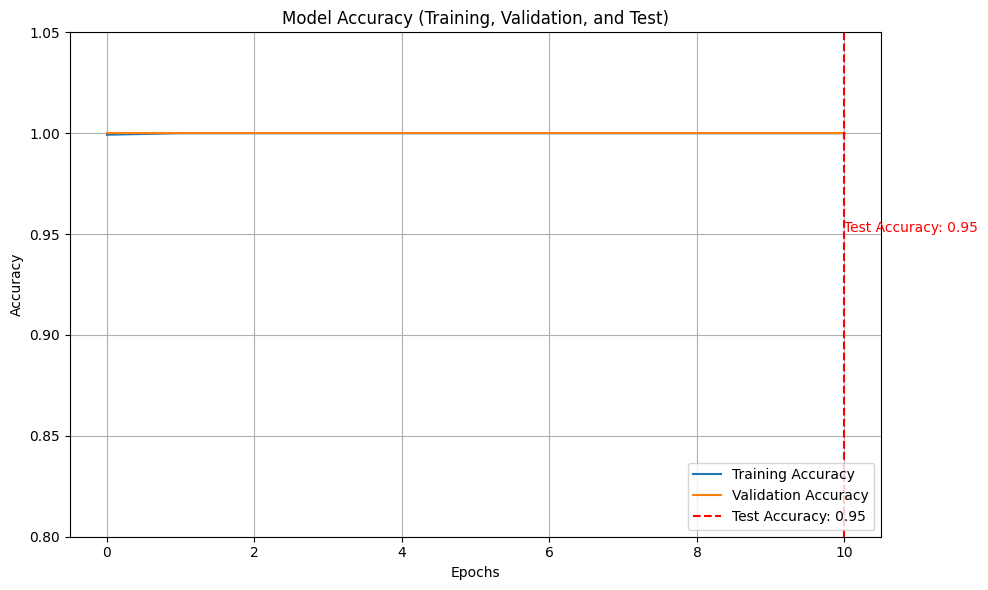

In [ ]:
import matplotlib.pyplot as plt

# Visualize Test Accuracy (compared to Training and Validation Accuracy)

# Assuming you have the 'history' object from model.fit(), which stores the training and validation accuracy
# and the test accuracy value after evaluating the model

plt.figure(figsize=(10, 6))

# Training and Validation Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Adding the Test Accuracy (you can manually add it if it isn't in the history)
test_accuracy = 0.9512277245521545  # Example: replace with actual test accuracy value from model evaluation
epochs = len(history.history['accuracy'])  # Get the number of epochs for alignment
plt.axvline(x=epochs-1, color='red', linestyle='--', label=f'Test Accuracy: {test_accuracy:.2f}')
plt.text(epochs-1, test_accuracy, f'Test Accuracy: {test_accuracy:.2f}', color='red')

plt.title('Model Accuracy (Training, Validation, and Test)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.ylim(0.8, 1.05) # Add this to zoom into the relevant accuracy range
plt.tight_layout() # Add this to adjust plot parameters for a tight layout
plt.show()

This cell draws a graph to compare the model's performance. It shows:

-   The **Training Accuracy** (blue line) and **Validation Accuracy** (orange line) during the learning process.
-   A red dashed line indicating the **Test Accuracy**, which is the model's final performance on completely new data. This helps us see if the model performs similarly on unseen data compared to the data it trained on.

In [ ]:
with open("/content/drive/MyDrive/max_len.txt", "w") as f:
    f.write(str(max_len))
print("max_len saved!")


max_len saved!


This cell saves the `max_len` value (the maximum length for our job descriptions) into a text file named `max_len.txt` in your Google Drive. This is useful so you can easily load this important setting later without having to recalculate it.

559/559 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


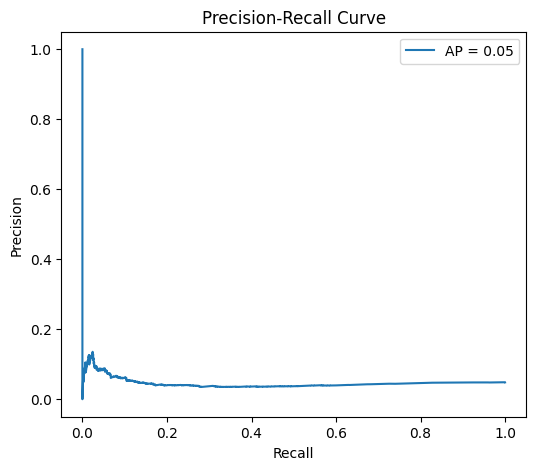

559/559 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
--- Detailed Classification Report ---
              precision    recall  f1-score   support

        REAL       0.95      1.00      0.98     17014
        FAKE       0.00      0.00      0.00       865

    accuracy                           0.95     17879
   macro avg       0.48      0.50      0.49     17879
weighted avg       0.91      0.95      0.93     17879



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report

# 1. PRECISION-RECALL CURVE (The "Robustness" Check)
def plot_precision_recall(model, X_test, y_test):
    y_prob = model.predict(X_test)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    avg_prec = average_precision_score(y_test, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f'AP = {avg_prec:.2f}')
    plt.title('Precision-Recall Curve')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.legend()
    plt.show()

# 2. CLASSIFICATION REPORT (The "Statistical Breakdown")
def print_detailed_report(model, X_test, y_test):
    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    print("--- Detailed Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=['REAL', 'FAKE']))

# Execute
plot_precision_recall(model, X_test_pad, y_test)
print_detailed_report(model, X_test_pad, y_test)